# Ejercicio 3 — Dataset Penguins

El dataset **Penguins** contiene información acerca de un conjunto de pingüinos que habitan el Archipiélago Palmer, un archipiélago del Océano Glacial Antártico. Puede importarse con `sns.load_dataset('penguins')`. Variables disponibles:

- **`species`**: especie (Chinstrap, Adélie o Gentoo).
- **`culmen_length_mm`**: largo del culmen, cresta superior del pico (mm).
- **`culmen_depth_mm`**: altura del culmen (mm).
- **`flipper_length_mm`**: largo de la aleta (mm).
- **`body_mass_g`**: masa corporal (g).
- **`island`**: nombre de la isla del Archipiélago Palmer (Dream, Torgersen o Biscoe).
- **`sex`**: sexo.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='ticks')

data_penguins = sns.load_dataset('penguins')
data_penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Ítem 1 — KDE: distribución de la longitud de aleta por especie

> **Reproduzca el gráfico mostrado en la figura para visualizar la distribución del largo de la aleta entre las distintas especies de pingüinos. En el mismo se utilizaron colores pertenecientes a la paleta `magma`.**

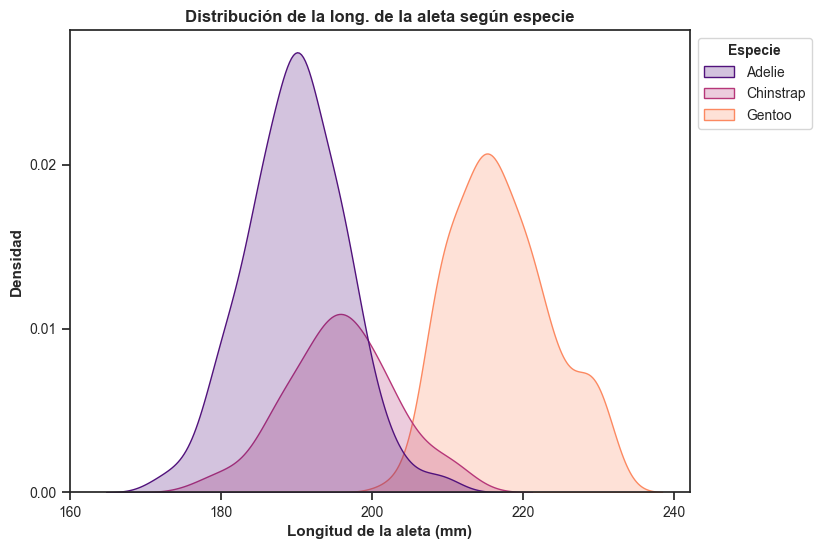

In [2]:
plt.figure(figsize=(8, 6))
ax = sns.kdeplot(x='flipper_length_mm', hue='species', fill=True,
                 data=data_penguins, palette='magma', common_norm=True)
plt.xlabel('Longitud de la aleta (mm)', fontweight='bold', fontsize=11)
plt.title('Distribución de la long. de la aleta según especie', fontweight='bold')
plt.xticks(np.arange(160, 241, 20), fontsize=10)
plt.yticks(np.arange(0, 0.021, 0.01), fontsize=10)
plt.ylabel('Densidad', fontweight='bold', fontsize=11)

legend = ax.get_legend()
legend.set_title('Especie')
legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(10)
legend.set_bbox_to_anchor((1, 1))
legend.set_loc('upper left')
for text in legend.get_texts():
    text.set_fontsize(10)

plt.show()

## Ítem 2 — Porcentaje de pingüinos por especie

> **Realice una tabla en la que se muestre qué porcentaje de pingüinos del dataset pertenece a cada una de las tres especies.**

In [3]:
tabla_especies = (data_penguins['species']
                  .value_counts()
                  .rename_axis('Especie')
                  .reset_index(name='Cantidad'))
tabla_especies['Porcentaje (%)'] = (tabla_especies['Cantidad'] / len(data_penguins) * 100).round(1)
display(tabla_especies)

,Especie,Cantidad,Porcentaje (%)
0,Adelie,152,44.2
1,Gentoo,124,36.0
2,Chinstrap,68,19.8


## Ítem 3 — Observación sobre `common_norm`

> **Teniendo en cuenta las características del gráfico realizado en el ítem 1 y la información contenida en la tabla realizada en el ítem 2, ¿qué observación puede realizar acerca de las curvas de densidad representadas para cada especie?**
>
> **Sugerencia:** dentro de la [documentación de Seaborn](https://seaborn.pydata.org/index.html), busque información sobre el parámetro `common_norm` de la función `kdeplot()` que utilizó para construir el gráfico.

### Respuesta

El parámetro `common_norm=True` normaliza las curvas de densidad de todas las especies conjuntamente, de modo que el área bajo **todas** las curvas suma 1. Como consecuencia, la especie más abundante (*Adélie*, ~44%) tiene la curva más alta, mientras que *Chinstrap* (~20%), la menos numerosa, tiene la curva más baja aunque su distribución sea similar en forma a la de *Adélie*.

Si se usara `common_norm=False`, cada curva representaría el 100% de su propia especie, independientemente del tamaño de cada grupo, lo que dificultaría comparar la presencia relativa de cada especie en el total.

## Ítem 4 — Percentil 90 de la longitud de aleta

> **¿A cuál de las tres especies se refiere la siguiente frase? "El 90% de los pingüinos presenta una longitud de aleta menor o igual a 198 mm."**

In [4]:
p90 = data_penguins.groupby('species')['flipper_length_mm'].quantile(0.90).round(1)
print('Percentil 90 de la longitud de aleta por especie:')
print(p90)
print()
especie_resp = p90[p90 <= 198].index.tolist()
print(f'Especie con P90 ≤ 198 mm: {especie_resp}')

Percentil 90 de la longitud de aleta por especie:
species
Adelie       198.0
Chinstrap    205.0
Gentoo       228.0
Name: flipper_length_mm, dtype: float64

Especie con P90 ≤ 198 mm: ['Adelie']


**Respuesta:** La frase corresponde a la especie *Adélie*, cuyo percentil 90 de longitud de aleta es el más cercano a 198 mm entre las tres especies.